## 🔧 SETUP

In [ ]:
# GPU Kontrolü
!nvidia-smi

import torch
print(f"\n🎯 GPU Info:")
print(f"   Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   Name: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

In [ ]:
# Kütüphane Kurulumu
!pip install -q sentence-transformers faiss-cpu pandas numpy matplotlib seaborn tqdm plotly

print("✅ Temel kütüphaneler yüklendi!")

In [ ]:
# Drive Bağlama
from google.colab import drive
drive.mount('/content/drive')

# Çalışma dizinini ayarla
import os
WORK_DIR = '/content/drive/MyDrive/Colab Notebooks/arxiv'
os.makedirs(WORK_DIR, exist_ok=True)

print(f"✅ Drive bağlandı!")
print(f"   Çalışma dizini: {WORK_DIR}")

Mounted at /content/drive
✅ Drive bağlandı!
   Çalışma dizini: /content/drive/MyDrive/Colab Notebooks/arxiv


In [ ]:
import sys
sys.path.append(WORK_DIR)

# Test et
try:
    from phase1_data_preparation import ArxivDataPreparation
    from phase2_embedding_comparison import EmbeddingModelComparison
    print("✅ Script'ler başarıyla yüklendi!")
except ImportError as e:
    print(f"❌ Script yüklenemedi: {e}")
    print("   Lütfen script'leri Drive'ınıza yükleyin!")

✅ Script'ler başarıyla yüklendi!


## 📊 PHASE 1: VERİ HAZIRLAMA


In [ ]:
# Veri dosya yolunu ayarlayın
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/arxiv/data/arxiv-metadata-oai-snapshot.json'
OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/arxiv/data/arxiv_processed_500k'

# Kontrol
import os
if os.path.exists(DATA_PATH):
    file_size_gb = os.path.getsize(DATA_PATH) / 1e9
    print(f"✅ Veri dosyası bulundu!")
    print(f"   Boyut: {file_size_gb:.2f} GB")
else:
    print(f"❌ Veri dosyası bulunamadı: {DATA_PATH}")
    print("   Lütfen ArXiv datasetini indirin ve Drive'a yükleyin!")

✅ Veri dosyası bulundu!
   Boyut: 4.98 GB


🚀 Phase 1 başlıyor...

🚀 PHASE 1: VERİ HAZIRLAMA BAŞLIYOR
📂 Veri yükleniyor (streaming mode)...
   ✓ 0 satır yüklendi...
   ✓ 100,000 satır yüklendi...
   ✓ 200,000 satır yüklendi...
   ✓ 300,000 satır yüklendi...
   ✓ 400,000 satır yüklendi...
   ✓ 500,000 satır yüklendi...
   ✓ 600,000 satır yüklendi...
   ✓ 700,000 satır yüklendi...
   ✓ 800,000 satır yüklendi...
   ✓ 900,000 satır yüklendi...
   ✓ 1,000,000 satır yüklendi...
   ✓ 1,100,000 satır yüklendi...
   ✓ 1,200,000 satır yüklendi...
   ✓ 1,300,000 satır yüklendi...
   ✓ 1,400,000 satır yüklendi...
   ✓ 1,500,000 satır yüklendi...
   ✓ 1,600,000 satır yüklendi...
   ✓ 1,700,000 satır yüklendi...
   ✓ 1,800,000 satır yüklendi...
   ✓ 1,900,000 satır yüklendi...
   ✓ 2,000,000 satır yüklendi...
✅ Toplam 2,100,000 satır yüklendi

🧹 Veri temizleniyor...
   • Boş değerler kontrol ediliyor...
   • Duplicate'ler kontrol ediliyor...
   • Minimum uzunluk kontrolü...
   • Kategoriler işleniyor...
   • Tarihler işleniyor...
   • Embeddi

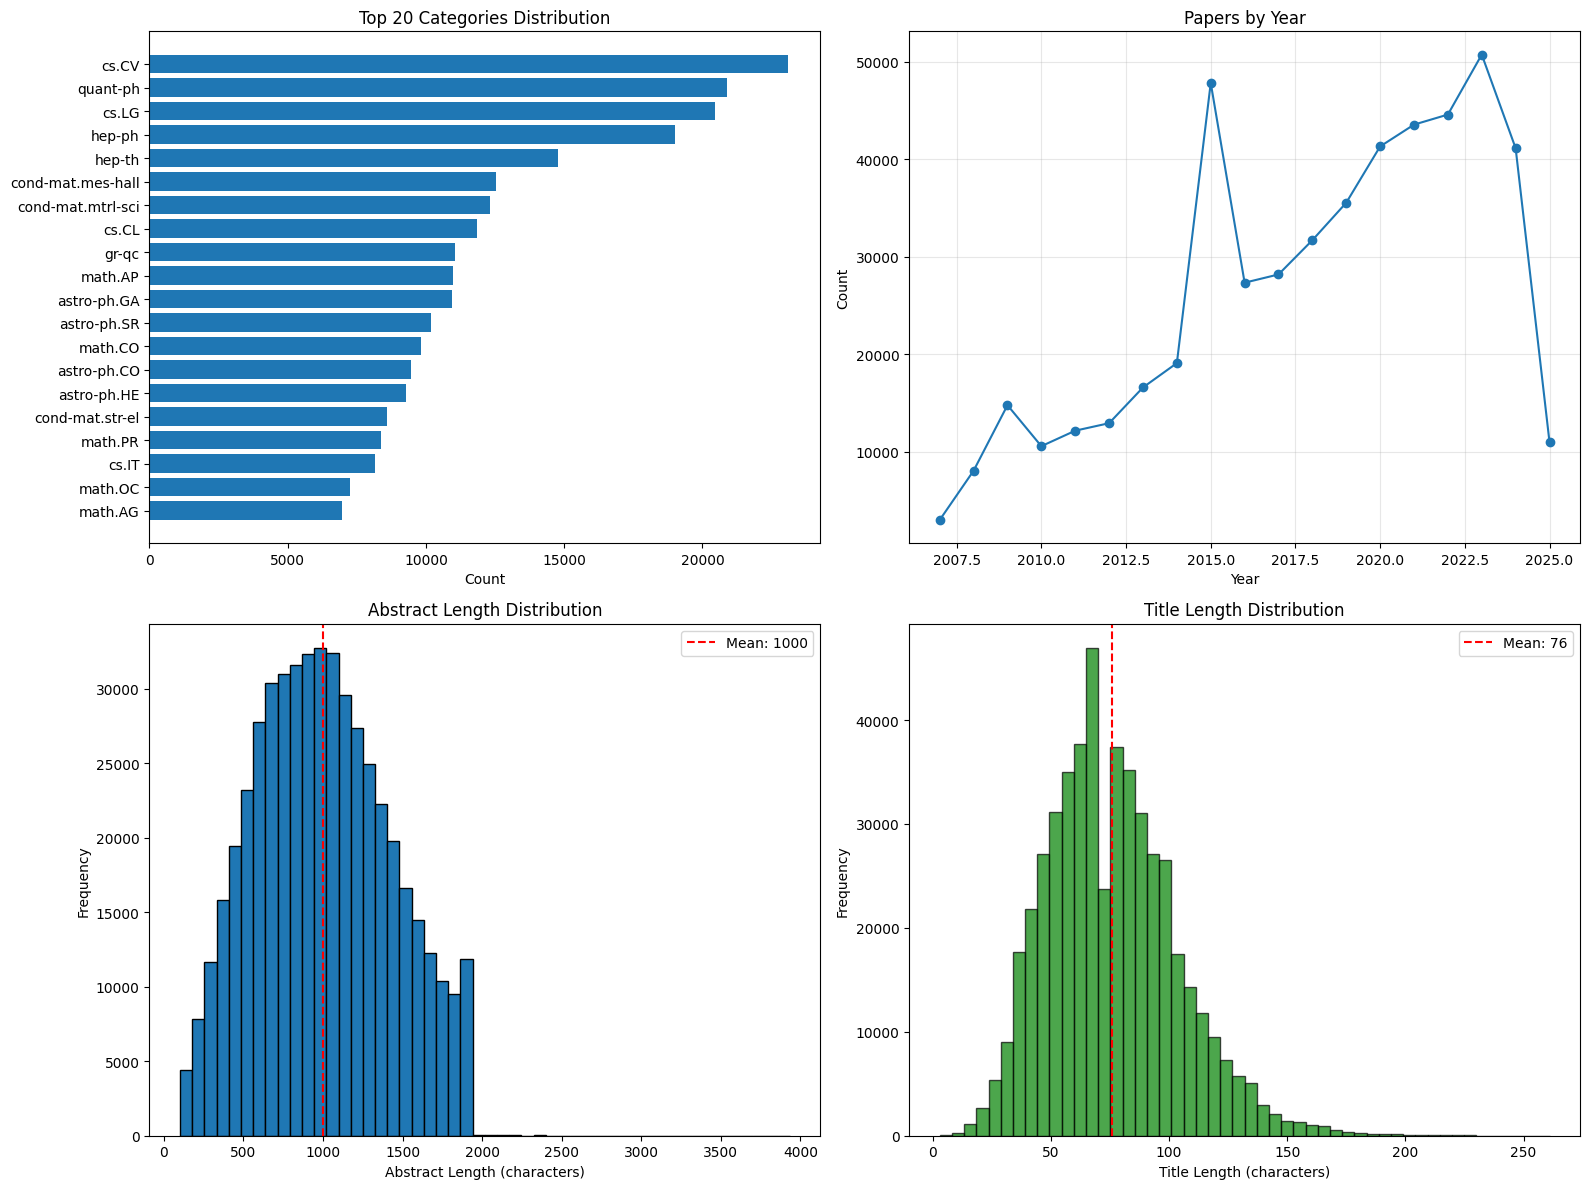


💾 Veri kaydediliyor: /content/drive/MyDrive/Colab Notebooks/arxiv/data/arxiv_processed_500k
   ✓ CSV kaydedildi: /content/drive/MyDrive/Colab Notebooks/arxiv/data/arxiv_processed_500k/arxiv_500k_processed.csv
   ✓ Pickle kaydedildi: /content/drive/MyDrive/Colab Notebooks/arxiv/data/arxiv_processed_500k/arxiv_500k_processed.pkl
   ✓ Metadata kaydedildi: /content/drive/MyDrive/Colab Notebooks/arxiv/data/arxiv_processed_500k/metadata.json
✅ Tüm veriler kaydedildi!

✅ PHASE 1 TAMAMLANDI!

✅ Phase 1 tamamlandı!
   Toplam veri: 500,000
   Kayıt yeri: /content/drive/MyDrive/Colab Notebooks/arxiv/data/arxiv_processed_500k/arxiv_500k_processed.pkl


In [ ]:
# Phase 1: Veri Hazırlama
from phase1_data_preparation import ArxivDataPreparation

print("🚀 Phase 1 başlıyor...\n")

prep = ArxivDataPreparation(
    data_path=DATA_PATH,
    target_size=500000  # 500K hedef
)

# Tüm pipeline'ı çalıştır
df, stats, paths = prep.run_complete_pipeline(output_dir=OUTPUT_DIR)

print(f"\n✅ Phase 1 tamamlandı!")
print(f"   Toplam veri: {len(df):,}")
print(f"   Kayıt yeri: {paths['pickle_path']}")

In [ ]:
# Veri istatistiklerini göster
import json

print("📊 Veri İstatistikleri:\n")
print(json.dumps(stats, indent=2))

📊 Veri İstatistikleri:

{
  "total_samples": 500000,
  "unique_categories": 153,
  "category_distribution": {
    "cs.CV": 23103,
    "quant-ph": 20890,
    "cs.LG": 20463,
    "hep-ph": 18999,
    "hep-th": 14777,
    "cond-mat.mes-hall": 12526,
    "cond-mat.mtrl-sci": 12318,
    "cs.CL": 11848,
    "gr-qc": 11049,
    "math.AP": 10976,
    "astro-ph.GA": 10937,
    "astro-ph.SR": 10193,
    "math.CO": 9821,
    "astro-ph.CO": 9473,
    "astro-ph.HE": 9268,
    "cond-mat.str-el": 8582,
    "math.PR": 8374,
    "cs.IT": 8174,
    "math.OC": 7270,
    "math.AG": 6958,
    "math.NT": 6864,
    "math.NA": 6603,
    "physics.optics": 6477,
    "cond-mat.stat-mech": 6201,
    "math-ph": 6015,
    "math.DG": 5778,
    "cs.RO": 5607,
    "astro-ph.EP": 5260,
    "cond-mat.supr-con": 5190,
    "cs.CR": 5183,
    "cond-mat.soft": 5172,
    "cs.AI": 5018,
    "nucl-th": 4960,
    "math.DS": 4863,
    "stat.ME": 4577,
    "physics.flu-dyn": 4275,
    "math.FA": 4260,
    "astro-ph": 4242,
    "a

## 🔤 PHASE 2: EMBEDDING KARŞILAŞTIRMA


In [ ]:
# Veri yükle
import pandas as pd

PICKLE_PATH = f"{OUTPUT_DIR}/arxiv_500k_processed.pkl"
df = pd.read_pickle(PICKLE_PATH)

print(f"✅ Veri yüklendi: {len(df):,} satır")
print(f"   Columns: {list(df.columns)}")

✅ Veri yüklendi: 500,000 satır
   Columns: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed', 'category_list', 'primary_category', 'year', 'embedding_text']


In [ ]:
# Embedding karşılaştırma objesi oluştur
from phase2_embedding_comparison import EmbeddingModelComparison

EMBEDDING_DIR = '/content/drive/MyDrive/Colab Notebooks/arxiv/data/arxiv_embeddings_500k'

comparison = EmbeddingModelComparison(
    data_df=df,
    output_dir=EMBEDDING_DIR
)

print("✅ Karşılaştırma objesi hazır!")
print("\nMevcut modeller:")
for key, model_info in comparison.MODELS.items():
    print(f"  • {key}: {model_info['description']} [{model_info['speed']} speed, {model_info['quality']} quality]")

✅ Karşılaştırma objesi hazır!

Mevcut modeller:
  • minilm: Lightweight, fast model [Very Fast speed, Good quality]
  • mpnet: Balanced model [Medium speed, Very Good quality]
  • bge: State-of-the-art model [Medium speed, Excellent quality]
  • e5: Multilingual model [Medium speed, Very Good quality]


In [ ]:
# MODEL 1: MiniLM (önce bunu test edin!)
print("🚀 Model 1: MiniLM başlıyor...\n")

embeddings_minilm, index_minilm = comparison.run_single_model(
    'minilm',
    batch_size=128  # A100 için optimize
)

# Sonuçları kaydet
comparison.save_results()

print("\n✅ MiniLM tamamlandı!")

In [ ]:
# MODEL 2: MPNet
print("🚀 Model 2: MPNet başlıyor...\n")

embeddings_mpnet, index_mpnet = comparison.run_single_model(
    'mpnet',
    batch_size=64  # 768 dim
)

comparison.save_results()
print("\n✅ MPNet tamamlandı!")

In [ ]:
# MODEL 3: BGE
print("🚀 Model 3: BGE başlıyor...\n")

embeddings_bge, index_bge = comparison.run_single_model(
    'bge',
    batch_size=64
)

comparison.save_results()
print("\n✅ BGE tamamlandı!")

📊 EMBEDDING MODEL KARŞILAŞTIRMASI


📊 KARŞILAŞTIRMA RAPORU

 Model  Dimension Embed Time (s) Speed (texts/s) Self-Retrieval Acc Avg Similarity Search Speed (q/s)
MINILM        384         405.98         1231.59             1.0000         0.4795            2533.53
 MPNET        768        2291.74          218.17             1.0000         0.4102            1398.33
   BGE        768        2257.74          221.46             1.0000         0.1592            1255.64

💾 Karşılaştırma tablosu kaydedildi: /content/drive/MyDrive/Colab Notebooks/arxiv/data/arxiv_embeddings_500k/model_comparison.csv

💾 Görselleştirme kaydedildi: /content/drive/MyDrive/Colab Notebooks/arxiv/data/arxiv_embeddings_500k/model_comparison_visualization.png


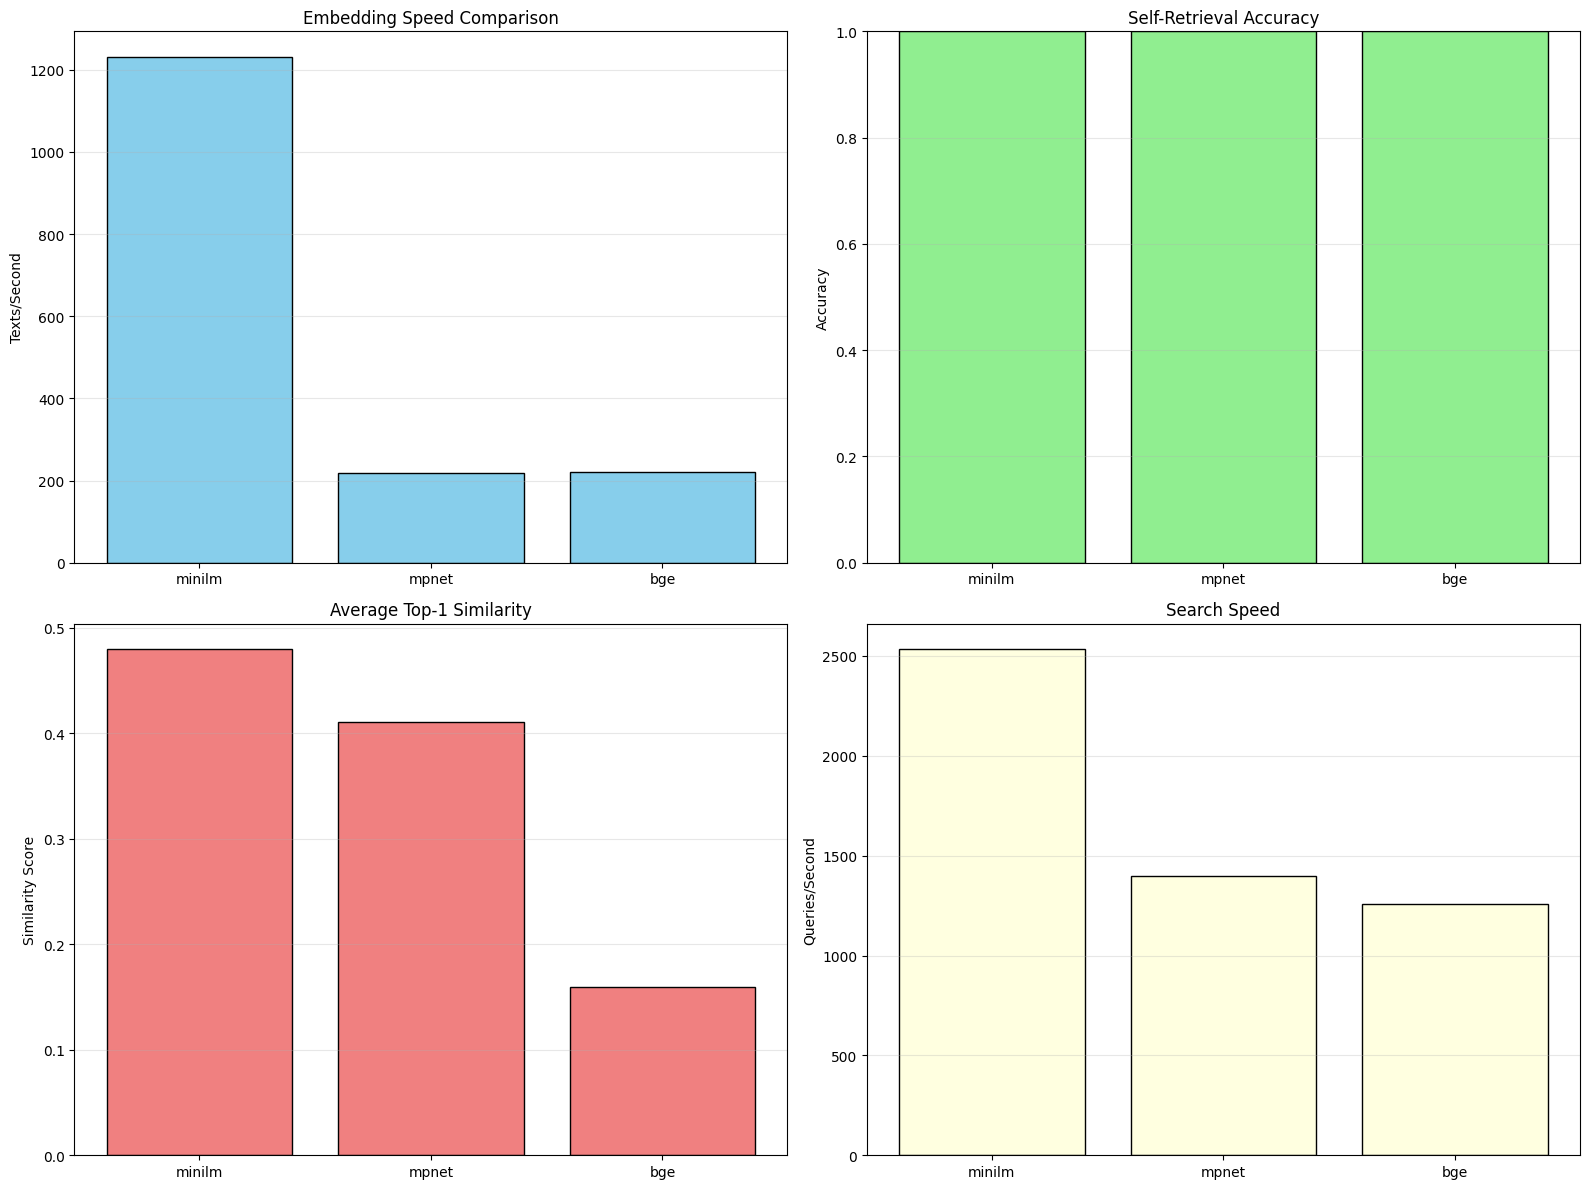


✅ Rapor oluşturuldu!


In [ ]:
# Karşılaştırma raporu
print("📊 EMBEDDING MODEL KARŞILAŞTIRMASI\n")

df_report = comparison.create_comparison_report()
comparison.visualize_comparison()

print("\n✅ Rapor oluşturuldu!")

## 🤖 PHASE 3: LLM KARŞILAŞTIRMA


In [ ]:
# LLM kütüphanesi kurulumu
!CMAKE_ARGS="-DLLAMA_CUBLAS=on" pip install llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu121

print("✅ llama-cpp-python kuruldu!")

In [ ]:
# RAG sistemi hazırlama
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
from phase3_llm_comparison import RAGSystem

# En iyi embedding modelini seç (Phase 2 sonuçlarına göre)
# Örnek: MPNet kullanıyoruz
BEST_MODEL = 'mpnet'

print(f"📥 RAG sistemi hazırlanıyor ({BEST_MODEL})...\n")

# Embedding model
embedding_model = SentenceTransformer(comparison.MODELS[BEST_MODEL]['name'])

# Veri ve index
df = pd.read_pickle(f"{OUTPUT_DIR}/arxiv_500k_processed.pkl")
embeddings = np.load(f"{EMBEDDING_DIR}/embeddings_{BEST_MODEL}.npy")
index = faiss.read_index(f"{EMBEDDING_DIR}/faiss_index_{BEST_MODEL}.index")

# RAG sistemi
rag_system = RAGSystem(df, index, embeddings, embedding_model)

print("✅ RAG sistemi hazır!")
print(f"   Veri: {len(df):,} doküman")
print(f"   Embedding dim: {embeddings.shape[1]}")

In [ ]:
# RAG test - retrieval kontrolü
test_query = "What is machine learning?"

print(f"Test Query: {test_query}\n")
retrieved = rag_system.retrieve(test_query, k=3)

for i, doc in enumerate(retrieved, 1):
    print(f"\n[{i}] Similarity: {doc['similarity']:.4f}")
    print(f"Title: {doc['title'][:100]}...")
    print(f"Category: {doc['category']}")

Test Query: What is machine learning?


[1] Similarity: 0.7750
Title: Patterns, predictions, and actions: A story about machine learning...
Category: cs.LG

[2] Similarity: 0.7799
Title: Machine Learning: When and Where the Horses Went Astray?...
Category: cs.AI

[3] Similarity: 0.8348
Title: What is Learning? A primary discussion about information and
  Representation...
Category: cs.AI


In [ ]:
# LLM test query'lerini hazırla
from phase3_llm_comparison import create_test_queries

test_queries = create_test_queries()

print(f"✅ {len(test_queries)} test query hazır\n")
print("Örnek query'ler:")
for i, q in enumerate(test_queries[:5], 1):
    print(f"  {i}. [{q['level']:12s}] {q['query']}")

✅ 12 test query hazır

Örnek query'ler:
  1. [beginner    ] What is machine learning?
  2. [beginner    ] How does artificial intelligence work?
  3. [beginner    ] What is a neural network?
  4. [intermediate] What is the difference between supervised and unsupervised learning?
  5. [intermediate] How do transformers work in natural language processing?


In [ ]:
# Model path'lerini ayarlayın
MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/arxiv/model'

# Mevcut modelleri kontrol et
import os
if os.path.exists(MODEL_DIR):
    print("📂 Mevcut GGUF modeller:\n")
    for f in os.listdir(MODEL_DIR):
        if f.endswith('.gguf'):
            size_mb = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1e6
            print(f"  • {f} ({size_mb:.0f} MB)")
else:
    print("❌ Model dizini bulunamadı!")
    print("   Lütfen GGUF modellerini indirin ve Drive'a yükleyin!")

📂 Mevcut GGUF modeller:

  • Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf (4921 MB)


In [ ]:
# LLM Karşılaştırma
from phase3_llm_comparison import LLMComparison

LLM_RESULTS_DIR = '/content/drive/MyDrive/Colab Notebooks/arxiv/llm_results_500k'

llm_comp = LLMComparison(
    rag_system=rag_system,
    output_dir=LLM_RESULTS_DIR
)

# Model path'lerini güncelle (kendi path'lerinize göre)
llm_comp.MODELS['llama-3.1-8b'].model_path = f"{MODEL_DIR}/Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf"

print("✅ LLM karşılaştırma objesi hazır!")

✅ LLM karşılaştırma objesi hazır!


In [ ]:
# MODEL TEST: Llama-3.1-8B
print("🚀 LLM Model Test: Llama-3.1-8B\n")

results_llama = llm_comp.run_test_queries(
    'llama-3.1-8b',
    test_queries,
    save_individual=True
)

print("\n✅ Llama-3.1-8B testi tamamlandı!")

🚀 LLM Model Test: Llama-3.1-8B


🚀 MODEL TEST: LLAMA-3.1-8B
   Query sayısı: 12

📥 Model yükleniyor: Llama-3.1-8B-Instruct
   Path: /content/drive/MyDrive/Colab Notebooks/arxiv/model/Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf


llama_context: n_ctx_per_seq (4096) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


✅ Model yüklendi!


Testing llama-3.1-8b:   0%|          | 0/12 [00:00<?, ?it/s]

📥 Model yükleniyor: Llama-3.1-8B-Instruct
   Path: /content/drive/MyDrive/Colab Notebooks/arxiv/model/Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf


...

📥 Model yükleniyor: Llama-3.1-8B-Instruct
   Path: /content/drive/MyDrive/Colab Notebooks/arxiv/model/Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf


llama_context: n_ctx_per_seq (4096) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


✅ Model yüklendi!


Testing llama-3.1-8b: 100%|██████████| 12/12 [01:49<00:00,  9.13s/it]


✅ LLAMA-3.1-8B testi tamamlandı!
   Başarılı: 12/12
   Ort. Generation Time: 4.38s
   Ort. Tokens/sec: 103.13

✅ Llama-3.1-8B testi tamamlandı!


In [ ]:
# Sonuçları incele
print("📊 LLM TEST SONUÇLARI\n")

# İlk birkaç sonucu göster
for i, result in enumerate(results_llama[:3], 1):
    if 'error' in result:
        print(f"\n[Query {i}] ❌ HATA: {result['error']}")
        continue

    print(f"\n{'='*80}")
    print(f"[Query {i}] Level: {result['level']}")
    print(f"Question: {result['query']}")
    print(f"\nAnswer:\n{result['answer'][:500]}...")
    print(f"\nMetrics:")
    print(f"  • Retrieve time: {result['retrieve_time']:.3f}s")
    print(f"  • Generation time: {result['generation_time']:.2f}s")
    print(f"  • Tokens/sec: {result['tokens_per_second']:.2f}")

📊 LLM TEST SONUÇLARI


[Query 1] Level: beginner
Question: What is machine learning?

Answer:
Machine learning is a way for computers to automatically improve their performance on a task by learning from data. Think of it like a student learning a new skill. Just as a student gets better at a subject by practicing and learning from their mistakes, a machine learning system gets better at a task by analyzing a large amount of data and making adjustments based on what it has learned.

Imagine you're trying to teach a child to recognize pictures of different animals. You show them many pict...

Metrics:
  • Retrieve time: 0.020s
  • Generation time: 3.35s
  • Tokens/sec: 97.19

[Query 2] Level: beginner
Question: How does artificial intelligence work?

Answer:
Artificial Intelligence (AI) is a way to make computers think and act like humans. But how does it actually work?

Imagine you're trying to learn how to recognize different types of fruits just by looking at pictures. A human brain 

In [ ]:
# Karşılaştırma raporu
df_llm_report = llm_comp.create_comparison_report()

print("\n✅ LLM karşılaştırma raporu oluşturuldu!")


📊 LLM KARŞILAŞTIRMA RAPORU

       Model Successful Queries Avg Retrieve (s) Avg Generation (s) Avg Tokens/sec Total Time (s)
LLAMA-3.1-8B              12/12            0.025               4.38         103.13          52.81

💾 Karşılaştırma kaydedildi: /content/drive/MyDrive/Colab Notebooks/arxiv/llm_results_500k/llm_comparison.csv

✅ LLM karşılaştırma raporu oluşturuldu!


## 📊 FINAL RESULTS

Tüm deney sonuçlarını topluca görüntüleyin

In [ ]:
# Sonuç özeti
import json

print("="*80)
print("🎯 DENEY SONUÇLARI ÖZETİ")
print("="*80)

print("\n1️⃣ PHASE 1: Veri Hazırlama")
print(f"   ✅ Toplam veri: {len(df):,} doküman")
print(f"   ✅ Kayıt yeri: {OUTPUT_DIR}")

print("\n2️⃣ PHASE 2: Embedding Karşılaştırma")
if comparison.results:
    for model_key in comparison.results.keys():
        r = comparison.results[model_key]
        print(f"   • {model_key.upper()}:")
        print(f"     - Embedding time: {r.get('embed_time', 0):.2f}s")
        print(f"     - Speed: {r.get('speed_texts_per_sec', 0):.2f} texts/sec")
        print(f"     - Retrieval acc: {r.get('self_retrieval_accuracy', 0):.4f}")

print("\n3️⃣ PHASE 3: LLM Karşılaştırma")
if llm_comp.results:
    for model_key in llm_comp.results.keys():
        r = llm_comp.results[model_key]
        print(f"   • {model_key.upper()}:")
        print(f"     - Successful: {r['successful_queries']}/{r['num_queries']}")
        print(f"     - Avg gen time: {r['avg_generation_time']:.2f}s")
        print(f"     - Avg tokens/sec: {r['avg_tokens_per_second']:.2f}")

print("\n" + "="*80)
print("✅ TÜM DENEYLER TAMAMLANDI!")
print("="*80)

🎯 DENEY SONUÇLARI ÖZETİ

1️⃣ PHASE 1: Veri Hazırlama
   ✅ Toplam veri: 500,000 doküman
   ✅ Kayıt yeri: /content/drive/MyDrive/Colab Notebooks/arxiv/data/arxiv_processed_500k

2️⃣ PHASE 2: Embedding Karşılaştırma
   • MINILM:
     - Embedding time: 405.98s
     - Speed: 1231.59 texts/sec
     - Retrieval acc: 1.0000
   • MPNET:
     - Embedding time: 2291.74s
     - Speed: 218.17 texts/sec
     - Retrieval acc: 1.0000
   • BGE:
     - Embedding time: 2257.74s
     - Speed: 221.46 texts/sec
     - Retrieval acc: 1.0000

3️⃣ PHASE 3: LLM Karşılaştırma
   • LLAMA-3.1-8B:
     - Successful: 12/12
     - Avg gen time: 4.38s
     - Avg tokens/sec: 103.13

✅ TÜM DENEYLER TAMAMLANDI!
